# Retrieval Evaluation

Scientific evaluation of our RAG system on the Attention Is All You Need paper.

Goals:
- Run the 5 test questions through our retrieval pipeline
- Measure retrieval quality with IR metrics
- Compare dense vs hybrid retrieval
- Identify where the system succeeds and fails

This is the notebook version of our A/B test — but focused on
one document with deep qualitative analysis.

In [2]:
import sys
sys.path.append('..')

from src.data.loader import DocumentLoader
from src.data.chunker import get_chunker
from src.retrieval.dense_retriever import DenseRetriever
from src.retrieval.hybrid_retriever import HybridRAGRetriever
from src.evaluation.retrieval_metrics import compute_all_metrics
from src.evaluation.ragas_eval import RAGASEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and index
loader = DocumentLoader()
docs   = loader.load("../src/data/raw/attention_is_all_you_need.pdf")

print(f"Loaded {len(docs)} pages")

2026-06-06 17:24:29 | INFO | src.data.loader | Loading PDF
2026-06-06 17:24:30 | INFO | src.data.loader | Loaded PDF
Loaded 15 pages


## Our test questions and ground truth

For each question we define:
- The question itself
- The expected answer (ground truth)
- Which pages should be retrieved (relevant pages)

In [3]:
test_cases = [
    {
        "question": "What problem does the Transformer architecture solve?",
        "ground_truth": "The Transformer solves the problem of sequential computation in recurrent models by using attention mechanisms entirely, allowing for more parallelization.",
        "relevant_pages": [1, 2],
    },
    {
        "question": "How does multi-head attention work?",
        "ground_truth": "Multi-head attention runs multiple attention operations in parallel across different representation subspaces, then concatenates and projects the results.",
        "relevant_pages": [4, 5],
    },
    {
        "question": "What BLEU scores did the Transformer achieve?",
        "ground_truth": "The Transformer achieved 28.4 BLEU on English-to-German and 41.0 BLEU on English-to-French translation tasks.",
        "relevant_pages": [8],
    },
    {
        "question": "What is positional encoding and why is it needed?",
        "ground_truth": "Positional encoding adds information about token position in the sequence since the model contains no recurrence or convolution.",
        "relevant_pages": [6],
    },
    {
        "question": "What optimizer and training settings were used?",
        "ground_truth": "The Adam optimizer was used with beta1=0.9, beta2=0.98 and a custom learning rate schedule with warmup steps.",
        "relevant_pages": [7],
    },
]

print(f"Test cases defined: {len(test_cases)}")
for i, tc in enumerate(test_cases, 1):
    print(f"  Q{i}: {tc['question'][:60]}...")

Test cases defined: 5
  Q1: What problem does the Transformer architecture solve?...
  Q2: How does multi-head attention work?...
  Q3: What BLEU scores did the Transformer achieve?...
  Q4: What is positional encoding and why is it needed?...
  Q5: What optimizer and training settings were used?...


## Dense Retrieval Evaluation

Index the paper with sliding window chunking and evaluate
each question using dense vector search only.

In [4]:
# Index with dense retriever
dense_retriever = DenseRetriever(chunking_strategy="sliding_window")
n_chunks = dense_retriever.index(docs)
print(f"Indexed {n_chunks} chunks\n")

evaluator = RAGASEvaluator()
dense_results = []

for i, tc in enumerate(test_cases, 1):
    question     = tc["question"]
    ground_truth = tc["ground_truth"]
    relevant_pages = set(tc["relevant_pages"])

    # Retrieve
    search_results = dense_retriever.retrieve_chunks(question, top_k=5)
    retrieved_pages = [r.chunk.metadata.get("page", 0) for r in search_results]
    contexts        = [r.chunk.content for r in search_results]

    # Check which retrieved pages are relevant
    retrieved_ids = [str(p) for p in retrieved_pages]
    relevant_ids  = {str(p) for p in relevant_pages}

    # Compute metrics
    metrics = compute_all_metrics(
        retrieved=retrieved_ids,
        relevant=relevant_ids,
        k_values=[1, 3, 5],
    )

    ragas = evaluator.evaluate(
        question=question,
        answer=ground_truth,
        contexts=contexts,
        ground_truth=ground_truth,
    )

    result = {
        "question":          f"Q{i}",
        "retrieved_pages":   retrieved_pages,
        "relevant_pages":    list(relevant_pages),
        "ndcg@5":            round(metrics["ndcg@5"], 4),
        "mrr":               round(metrics["mrr"], 4),
        "precision@3":       round(metrics["precision@3"], 4),
        "faithfulness":      round(ragas["faithfulness"], 4),
        "context_precision": round(ragas["context_precision"], 4),
        "top_score":         round(search_results[0].score, 4),
    }
    dense_results.append(result)

    print(f"Q{i}: {question[:50]}...")
    print(f"     Retrieved pages: {retrieved_pages}")
    print(f"     Relevant pages:  {list(relevant_pages)}")
    print(f"     NDCG@5={metrics['ndcg@5']:.4f} | MRR={metrics['mrr']:.4f} | Faith={ragas['faithfulness']:.4f}")
    print()

df_dense = pd.DataFrame(dense_results)

2026-06-06 17:25:11 | INFO | src.vectorstore.chroma_store | Initializing ChromaVectorStore
2026-06-06 17:25:11 | INFO | src.retrieval.dense_retriever | Initialized DenseRetriever
2026-06-06 17:25:11 | INFO | src.retrieval.dense_retriever | Indexing documents
2026-06-06 17:25:11 | INFO | src.data.chunker | Sliding window chunking complete
2026-06-06 17:25:11 | INFO | src.retrieval.dense_retriever | Chunking complete


c:\Users\Snapp\anaconda3\envs\rag-eval\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-06 17:25:20 | INFO | src.embeddings.dense | Loading dense embedding model


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


2026-06-06 17:25:27 | INFO | src.vectorstore.chroma_store | Added chunks to ChromaDB
2026-06-06 17:25:27 | INFO | src.retrieval.dense_retriever | Indexing complete
Indexed 21 chunks

2026-06-06 17:25:27 | INFO | src.embeddings.dense | Loading dense embedding model


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8400.03it/s]


Q1: What problem does the Transformer architecture sol...
     Retrieved pages: [3, 8, 5, 8, 9]
     Relevant pages:  [1, 2]
     NDCG@5=0.0000 | MRR=0.0000 | Faith=0.5383

Q2: How does multi-head attention work?...
     Retrieved pages: [5, 13, 15, 14, 3]
     Relevant pages:  [4, 5]
     NDCG@5=0.6131 | MRR=1.0000 | Faith=0.7205

Q3: What BLEU scores did the Transformer achieve?...
     Retrieved pages: [8, 8, 9, 10, 9]
     Relevant pages:  [8]
     NDCG@5=1.6309 | MRR=1.0000 | Faith=0.5992

Q4: What is positional encoding and why is it needed?...
     Retrieved pages: [6, 3, 2, 5, 7]
     Relevant pages:  [6]
     NDCG@5=1.0000 | MRR=1.0000 | Faith=0.5436

Q5: What optimizer and training settings were used?...
     Retrieved pages: [7, 8, 8, 9, 5]
     Relevant pages:  [7]
     NDCG@5=1.0000 | MRR=1.0000 | Faith=0.5103



## Hybrid Retrieval Evaluation

Now index with hybrid retrieval (dense + BM25) and compare.
Hypothesis: hybrid search will perform better on keyword-specific
questions like "BLEU scores" and "Adam optimizer".

In [5]:
hybrid_retriever = HybridRAGRetriever(
    chunking_strategy="sliding_window",
    use_reranker=False,
)
hybrid_retriever.index(docs)
print("Hybrid index built\n")

hybrid_results = []

for i, tc in enumerate(test_cases, 1):
    question       = tc["question"]
    ground_truth   = tc["ground_truth"]
    relevant_pages = set(tc["relevant_pages"])

    search_results  = hybrid_retriever.retrieve_chunks(question, top_k=5)
    retrieved_pages = [r.chunk.metadata.get("page", 0) for r in search_results]
    contexts        = [r.chunk.content for r in search_results]

    retrieved_ids = [str(p) for p in retrieved_pages]
    relevant_ids  = {str(p) for p in relevant_pages}

    metrics = compute_all_metrics(
        retrieved=retrieved_ids,
        relevant=relevant_ids,
        k_values=[1, 3, 5],
    )

    ragas = evaluator.evaluate(
        question=question,
        answer=ground_truth,
        contexts=contexts,
        ground_truth=ground_truth,
    )

    result = {
        "question":          f"Q{i}",
        "retrieved_pages":   retrieved_pages,
        "relevant_pages":    list(relevant_pages),
        "ndcg@5":            round(metrics["ndcg@5"], 4),
        "mrr":               round(metrics["mrr"], 4),
        "precision@3":       round(metrics["precision@3"], 4),
        "faithfulness":      round(ragas["faithfulness"], 4),
        "context_precision": round(ragas["context_precision"], 4),
        "top_score":         round(search_results[0].score, 4),
    }
    hybrid_results.append(result)

    print(f"Q{i}: {question[:50]}...")
    print(f"     Retrieved pages: {retrieved_pages}")
    print(f"     NDCG@5={metrics['ndcg@5']:.4f} | MRR={metrics['mrr']:.4f} | Faith={ragas['faithfulness']:.4f}")
    print()

df_hybrid = pd.DataFrame(hybrid_results)

2026-06-06 17:25:52 | INFO | src.retrieval.hybrid_retriever | Initialized HybridRAGRetriever
2026-06-06 17:25:52 | INFO | src.retrieval.hybrid_retriever | Indexing documents for hybrid retrieval
2026-06-06 17:25:52 | INFO | src.data.chunker | Sliding window chunking complete
2026-06-06 17:25:52 | INFO | src.embeddings.hybrid | Building hybrid index
2026-06-06 17:25:52 | INFO | src.embeddings.sparse | Building BM25 index
2026-06-06 17:25:52 | INFO | src.embeddings.sparse | BM25 index built
2026-06-06 17:25:52 | INFO | src.embeddings.dense | Loading dense embedding model


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.46it/s]

2026-06-06 17:26:01 | INFO | src.embeddings.hybrid | Hybrid index built
2026-06-06 17:26:01 | INFO | src.retrieval.hybrid_retriever | Hybrid index built


Hybrid index built

Q1: What problem does the Transformer architecture sol...
     Retrieved pages: [3, 2, 9, 8, 1]
     NDCG@5=0.6241 | MRR=0.5000 | Faith=0.5383

Q2: How does multi-head attention work?...
     Retrieved pages: [5, 4, 3, 14, 1]
     NDCG@5=1.0000 | MRR=1.0000 | Faith=0.7205

Q3: What BLEU scores did the Transformer achieve?...
     Retrieved pages: [8, 9, 10, 8, 1]
     NDCG@5=1.4307 | MRR=1.0000 | Faith=0.5992

Q4: What is positional encoding and why is it needed?...
     Retrieved pages: [6, 9, 7, 3, 13]
     NDCG@5=1.0000 | MRR=1.0000 | Faith=0.5436

Q5: What optimizer and training settings were used?...
     Retrieved pages: [8, 7, 8, 14, 9]
     NDCG@5=0.6309 | MRR=0.5000 | Faith=0.3344



## Comparison: Dense vs Hybrid

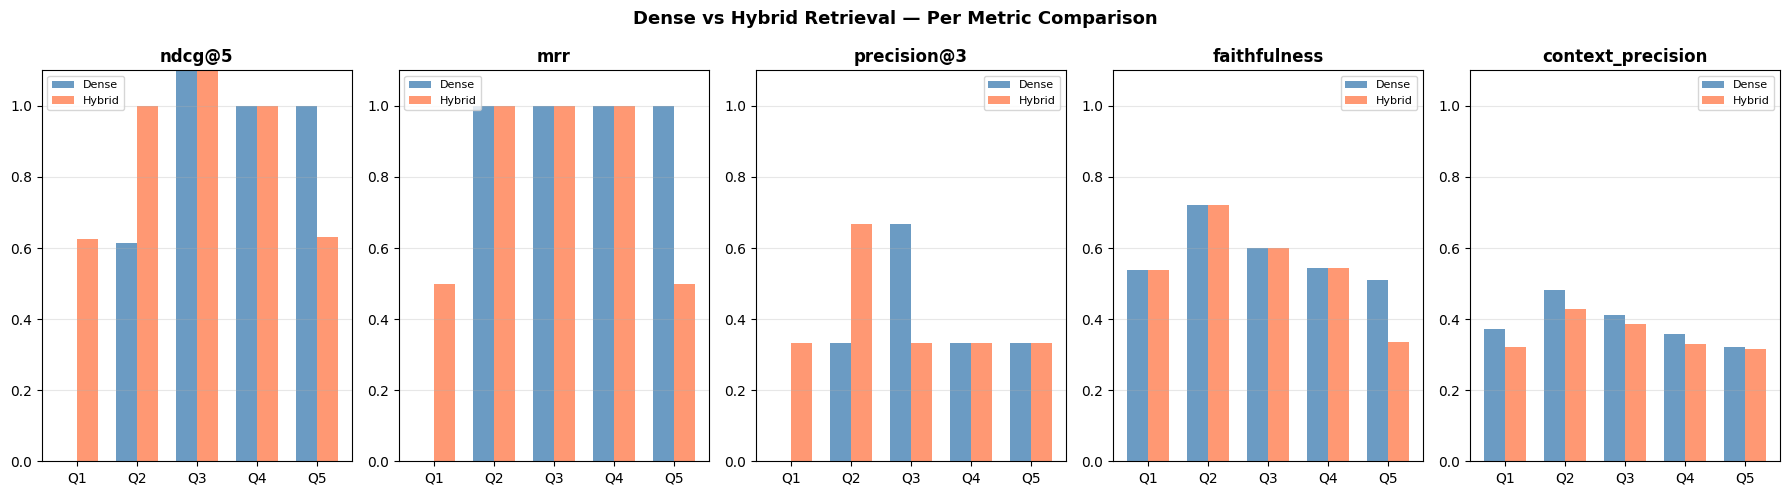

In [7]:
metrics_to_compare = ["ndcg@5", "mrr", "precision@3", "faithfulness", "context_precision"]

fig, axes = plt.subplots(1, len(metrics_to_compare), figsize=(18, 5))
fig.suptitle("Dense vs Hybrid Retrieval — Per Metric Comparison", 
             fontsize=13, fontweight='bold')

questions = [f"Q{i+1}" for i in range(len(test_cases))]
x = np.arange(len(questions))
width = 0.35

for idx, metric in enumerate(metrics_to_compare):
    dense_scores  = df_dense[metric].values
    hybrid_scores = df_hybrid[metric].values

    axes[idx].bar(x - width/2, dense_scores,  width, label='Dense',  color='steelblue', alpha=0.8)
    axes[idx].bar(x + width/2, hybrid_scores, width, label='Hybrid', color='coral',     alpha=0.8)
    axes[idx].set_title(metric, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(questions)
    axes[idx].set_ylim(0, 1.1)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../src/data/eval_datasets/dense_vs_hybrid.png", dpi=150)
plt.show()

In [8]:
print("\n" + "="*65)
print("DENSE vs HYBRID — AVERAGED ACROSS ALL QUESTIONS")
print("="*65)
print(f"{'Metric':<20} {'Dense':>12} {'Hybrid':>12} {'Winner':>12}")
print("-"*65)

for metric in metrics_to_compare:
    dense_avg  = df_dense[metric].mean()
    hybrid_avg = df_hybrid[metric].mean()
    winner     = "Hybrid" if hybrid_avg > dense_avg else "Dense"
    diff       = abs(hybrid_avg - dense_avg)
    print(f"{metric:<20} {dense_avg:>12.4f} {hybrid_avg:>12.4f} {winner:>12} (+{diff:.4f})")

print("="*65)


DENSE vs HYBRID — AVERAGED ACROSS ALL QUESTIONS
Metric                      Dense       Hybrid       Winner
-----------------------------------------------------------------
ndcg@5                     0.8488       0.9371       Hybrid (+0.0883)
mrr                        0.8000       0.8000        Dense (+0.0000)
precision@3                0.3333       0.4000       Hybrid (+0.0667)
faithfulness               0.5824       0.5472        Dense (+0.0352)
context_precision          0.3891       0.3562        Dense (+0.0330)


In [9]:
print("\nFAILURE ANALYSIS — Questions where retrieval failed\n")

for i, (dense, hybrid) in enumerate(zip(dense_results, hybrid_results)):
    q = test_cases[i]["question"]
    relevant = set(str(p) for p in test_cases[i]["relevant_pages"])
    
    dense_retrieved  = set(str(p) for p in dense["retrieved_pages"][:3])
    hybrid_retrieved = set(str(p) for p in hybrid["retrieved_pages"][:3])
    
    dense_hit  = bool(dense_retrieved  & relevant)
    hybrid_hit = bool(hybrid_retrieved & relevant)
    
    status = ""
    if not dense_hit and not hybrid_hit:
        status = "BOTH FAILED"
    elif not dense_hit and hybrid_hit:
        status = "Dense failed, Hybrid saved it"
    elif dense_hit and not hybrid_hit:
        status = "Hybrid failed, Dense saved it"
    else:
        status = "Both succeeded"
    
    print(f"Q{i+1}: {q[:55]}...")
    print(f"     Status: {status}")
    print(f"     Relevant pages: {test_cases[i]['relevant_pages']}")
    print(f"     Dense top-3:    {dense['retrieved_pages'][:3]}")
    print(f"     Hybrid top-3:   {hybrid['retrieved_pages'][:3]}")
    print()


FAILURE ANALYSIS — Questions where retrieval failed

Q1: What problem does the Transformer architecture solve?...
     Status: Dense failed, Hybrid saved it
     Relevant pages: [1, 2]
     Dense top-3:    [3, 8, 5]
     Hybrid top-3:   [3, 2, 9]

Q2: How does multi-head attention work?...
     Status: Both succeeded
     Relevant pages: [4, 5]
     Dense top-3:    [5, 13, 15]
     Hybrid top-3:   [5, 4, 3]

Q3: What BLEU scores did the Transformer achieve?...
     Status: Both succeeded
     Relevant pages: [8]
     Dense top-3:    [8, 8, 9]
     Hybrid top-3:   [8, 9, 10]

Q4: What is positional encoding and why is it needed?...
     Status: Both succeeded
     Relevant pages: [6]
     Dense top-3:    [6, 3, 2]
     Hybrid top-3:   [6, 9, 7]

Q5: What optimizer and training settings were used?...
     Status: Both succeeded
     Relevant pages: [7]
     Dense top-3:    [7, 8, 8]
     Hybrid top-3:   [8, 7, 8]

